# Compute nearest network access

Connect grid-cell centroids and hospital locations to the road network, then compute the network distance from each grid cell to its nearest hospital.

In [1]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import (
    CITY_NAME,
    CRS_WGS84,
    CRS_PROJECTED,
    FILES,
    ensure_project_dirs,
    savefig,
    print_config_summary,
)

ensure_project_dirs()
print_config_summary()

===== CONFIG =====
City: Nairobi
BBOX: {'lon_min': 36.6, 'lat_min': -1.5, 'lon_max': 37.1, 'lat_max': -1.1}
Grid Size: 1000 m
Top-K Hospitals: 3
Alpha: 1.5
Beta: 1.0
HRSL Path: /Users/suvo/Projects/urban-healthcare/data/raw/population/hrsl_kenya.tif


In [2]:
grid = gpd.read_parquet(FILES["grid_population"])
hospitals = gpd.read_parquet(FILES["hospitals"])
roads = ox.load_graphml(FILES["roads_graphml"])

print("Grid cells:", len(grid))
print("Hospitals:", len(hospitals))
print("Road nodes:", len(roads.nodes))
print("Road edges:", len(roads.edges))

Grid cells: 2520
Hospitals: 326
Road nodes: 86640
Road edges: 212368


In [3]:
grid = grid.to_crs(CRS_PROJECTED)
hospitals = hospitals.to_crs(CRS_PROJECTED)

grid["centroid"] = grid.geometry.centroid
grid_centroids = gpd.GeoDataFrame(
    grid[["grid_id", "population", "population_density_km2"]].copy(),
    geometry=grid["centroid"],
    crs=CRS_PROJECTED,
)

grid_centroids.head()

,grid_id,population,population_density_km2,geometry
0,g_00000,0.000000,0.000000,POINT (4074793.363 -166498.314)
1,g_00001,13.913320,13.913320,POINT (4074793.363 -165498.314)
2,g_00002,13.913320,13.913320,POINT (4074793.363 -164498.314)
3,g_00003,16.695984,16.695984,POINT (4074793.363 -163498.314)
4,g_00004,91.827912,91.827912,POINT (4074793.363 -162498.314)


In [4]:
nodes_gdf, edges_gdf = ox.graph_to_gdfs(roads)

print("Road graph CRS:", nodes_gdf.crs)
print("Nodes CRS:", nodes_gdf.crs)
print("Edges CRS:", edges_gdf.crs)

Road graph CRS: epsg:4326
Nodes CRS: epsg:4326
Edges CRS: epsg:4326


In [5]:
# Recompute graph CRS AFTER projection
nodes_gdf, _ = ox.graph_to_gdfs(roads)
graph_crs = nodes_gdf.crs

print("Graph CRS:", graph_crs)

# Project everything correctly
grid_centroids = grid_centroids.to_crs(graph_crs)
hospitals = hospitals.to_crs(graph_crs)

print("Grid centroid CRS:", grid_centroids.crs)
print("Hospital CRS:", hospitals.crs)

Graph CRS: epsg:4326
Grid centroid CRS: epsg:4326
Hospital CRS: epsg:4326


In [6]:
# Snap grid centroids to nearest road nodes
grid_centroids["nearest_node"] = ox.distance.nearest_nodes(
    roads,
    X=grid_centroids.geometry.x.to_numpy(),
    Y=grid_centroids.geometry.y.to_numpy()
)

# Snap hospitals to nearest road nodes
hospitals["nearest_node"] = ox.distance.nearest_nodes(
    roads,
    X=hospitals.geometry.x.to_numpy(),
    Y=hospitals.geometry.y.to_numpy()
)

print("Unique hospital nodes:", hospitals["nearest_node"].nunique())
grid_centroids.head()

Unique hospital nodes: 280


,grid_id,population,population_density_km2,geometry,nearest_node
0,g_00000,0.000000,0.000000,POINT (36.60449 -1.49551),6285881207
1,g_00001,13.913320,13.913320,POINT (36.60449 -1.48653),6337914595
2,g_00002,13.913320,13.913320,POINT (36.60449 -1.47755),6337914595
3,g_00003,16.695984,16.695984,POINT (36.60449 -1.46857),6337903905
4,g_00004,91.827912,91.827912,POINT (36.60449 -1.45959),6300726455


In [7]:
hospital_node_set = set(hospitals["nearest_node"].unique())
print("Hospital node count:", len(hospital_node_set))

Hospital node count: 280


In [8]:
# Reverse shortest path from all hospital nodes at once
nearest_distances = nx.multi_source_dijkstra_path_length(
    roads,
    hospital_node_set,
    weight="length"
)

print("Reachable road nodes:", len(nearest_distances))

Reachable road nodes: 86625


In [9]:
grid_centroids["nearest_hospital_distance_m"] = grid_centroids["nearest_node"].map(nearest_distances)

missing_count = grid_centroids["nearest_hospital_distance_m"].isna().sum()

print("Missing distance values:", missing_count)
print("Min distance (m):", grid_centroids["nearest_hospital_distance_m"].min())
print("Median distance (m):", grid_centroids["nearest_hospital_distance_m"].median())
print("Max distance (m):", grid_centroids["nearest_hospital_distance_m"].max())

Missing distance values: 0
Min distance (m): 0.0
Median distance (m): 6031.198204945313
Max distance (m): 26126.851944813538


In [10]:
nearest_access = grid.merge(
    grid_centroids[["grid_id", "nearest_node", "nearest_hospital_distance_m"]],
    on="grid_id",
    how="left"
)

nearest_access.head()

,grid_id,geometry,cell_area_m2,cell_area_km2,population,population_density_km2,centroid,nearest_node,nearest_hospital_distance_m
0,g_00000,"POLYGON ((4075293.363 -165998.314, 4075293.363...",1000000.0,1.0,0.000000,0.000000,POINT (4074793.363 -166498.314),6285881207,18919.701825
1,g_00001,"POLYGON ((4075293.363 -164998.314, 4075293.363...",1000000.0,1.0,13.913320,13.913320,POINT (4074793.363 -165498.314),6337914595,19302.596780
2,g_00002,"POLYGON ((4075293.363 -163998.314, 4075293.363...",1000000.0,1.0,13.913320,13.913320,POINT (4074793.363 -164498.314),6337914595,19302.596780
3,g_00003,"POLYGON ((4075293.363 -162998.314, 4075293.363...",1000000.0,1.0,16.695984,16.695984,POINT (4074793.363 -163498.314),6337903905,21495.756410
4,g_00004,"POLYGON ((4075293.363 -161998.314, 4075293.363...",1000000.0,1.0,91.827912,91.827912,POINT (4074793.363 -162498.314),6300726455,20307.217036


Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/05_nearest_hospital_distance_network.png


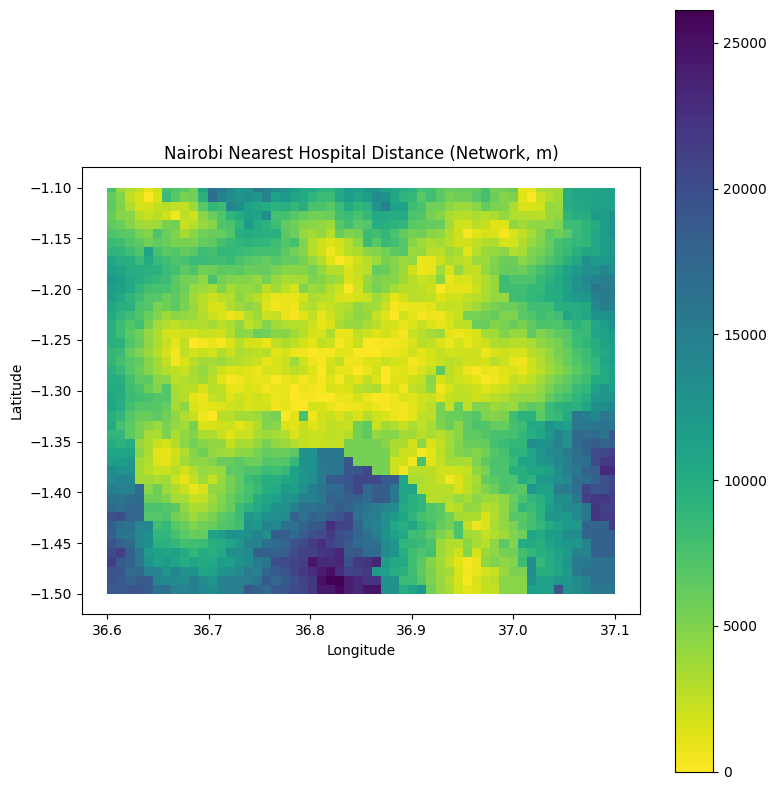

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))

nearest_access_wgs84 = nearest_access.to_crs(CRS_WGS84)

nearest_access_wgs84.plot(
    column="nearest_hospital_distance_m",
    ax=ax,
    cmap="viridis_r",
    legend=True,
    linewidth=0
)

ax.set_title(f"{CITY_NAME} Nearest Hospital Distance (Network, m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()

savefig(fig, "05_nearest_hospital_distance_network.png")
plt.show()

In [12]:
nearest_access.to_parquet(FILES["nearest_access"], index=False)
print("Saved nearest access to:", FILES["nearest_access"])

Saved nearest access to: /Users/suvo/Projects/urban-healthcare/data/processed/nearest_access.parquet
